# Task 2.3 - Hyperparameter Experimentation

## Objective
Run controlled experiments on a PyTorch neural network, varying one hyperparameter
group at a time (learning rate, optimizer, batch size, epochs), while keeping the
dataset, architecture, and evaluation procedure fixed. Compare results in a structured
table and select a final configuration based on the evidence.

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import time

print("Torch version:", torch.__version__)

Torch version: 2.14.0+cpu


## Data Pipeline (Fixed for All Experiments)

We reuse the California Housing setup from Task 2.1. The train/test split, scaling,
and random seed stay identical across every experiment so that any difference in
results comes from the hyperparameters, not the data.

In [3]:
# Fix random seed so results are reproducible
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Load data
housing = fetch_california_housing(as_frame=True)
df = housing.frame

X = df.drop(columns=["MedHouseVal"]).values
y = df["MedHouseVal"].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# Scale (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("Train:", X_train_t.shape, y_train_t.shape)
print("Test:", X_test_t.shape, y_test_t.shape)

Train: torch.Size([16512, 8]) torch.Size([16512, 1])
Test: torch.Size([4128, 8]) torch.Size([4128, 1])


## Reusable Experiment Function

One function that builds a fresh model, trains it with the given hyperparameters,
and returns the results. Architecture and data stay fixed; only the hyperparameters
passed in change.

In [4]:
def build_model():
    """Same architecture as Task 2.1: 8 -> 32 -> 16 -> 1"""
    return nn.Sequential(
        nn.Linear(8, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )


def evaluate(model, X, y, criterion):
    """Return MSE loss on the given data (no weight updates)."""
    model.eval()
    with torch.no_grad():
        preds = model(X)
        loss = criterion(preds, y)
    return loss.item()


def run_experiment(run_id, optimizer_name="Adam", lr=0.001, batch_size=32, epochs=30):
    # Same seed every run, so every experiment starts from identical initial weights
    torch.manual_seed(SEED)

    model = build_model()
    criterion = nn.MSELoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "RMSprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    train_curve, test_curve = [], []
    start = time.time()

    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

        # Measure loss on full train and test sets after each epoch
        train_curve.append(evaluate(model, X_train_t, y_train_t, criterion))
        test_curve.append(evaluate(model, X_test_t, y_test_t, criterion))

    elapsed = time.time() - start

    return {
        "run_id": run_id,
        "optimizer": optimizer_name,
        "lr": lr,
        "batch_size": batch_size,
        "epochs": epochs,
        "final_train_loss": round(train_curve[-1], 4),
        "final_test_loss": round(test_curve[-1], 4),
        "time_sec": round(elapsed, 1),
        "train_curve": train_curve,
        "test_curve": test_curve,
    }

In [5]:
test_run = run_experiment(run_id="TEST", epochs=2)
print({k: v for k, v in test_run.items() if k not in ("train_curve", "test_curve")})

{'run_id': 'TEST', 'optimizer': 'Adam', 'lr': 0.001, 'batch_size': 32, 'epochs': 2, 'final_train_loss': 0.4299, 'final_test_loss': 0.446, 'time_sec': 1.4}


## Group A: Learning Rate

Only the learning rate changes (0.01, 0.001, 0.0001). Optimizer (Adam), batch size (32),
and epochs (30) stay fixed.

In [6]:
results = []   # this list will collect every experiment's result

for i, lr in enumerate([0.01, 0.001, 0.0001], start=1):
    print(f"Running A{i}: lr={lr} ...")
    r = run_experiment(run_id=f"A{i}", optimizer_name="Adam", lr=lr, batch_size=32, epochs=30)
    results.append(r)
    print(f"  done -> train loss {r['final_train_loss']}, test loss {r['final_test_loss']}, {r['time_sec']}s")

Running A1: lr=0.01 ...
  done -> train loss 0.282, test loss 0.2994, 21.9s
Running A2: lr=0.001 ...
  done -> train loss 0.278, test loss 0.2915, 31.2s
Running A3: lr=0.0001 ...
  done -> train loss 0.3798, test loss 0.39, 22.5s


## Group A Results

Test loss per epoch for each learning rate. Best learning rate: 0.001.

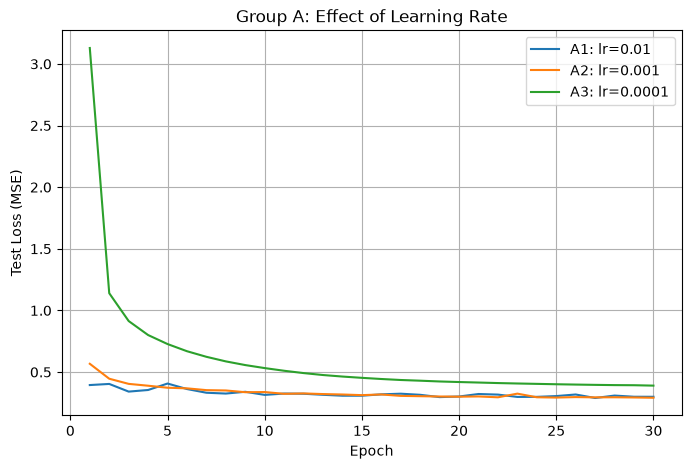

In [7]:
plt.figure(figsize=(8, 5))
for r in results:
    plt.plot(range(1, r["epochs"] + 1), r["test_curve"], label=f"{r['run_id']}: lr={r['lr']}")
plt.xlabel("Epoch")
plt.ylabel("Test Loss (MSE)")
plt.title("Group A: Effect of Learning Rate")
plt.legend()
plt.grid(True)
plt.show()

## Group B: Optimizer

Only the optimizer changes (Adam, SGD, RMSprop). Learning rate (0.001, best from Group A),
batch size (32), and epochs (30) stay fixed.

In [8]:
# Adam with lr=0.001 is already run as A2, so we reuse it as the Adam baseline.
# We only need to run SGD and RMSprop here.
for i, opt in enumerate(["SGD", "RMSprop"], start=1):
    print(f"Running B{i}: optimizer={opt} ...")
    r = run_experiment(run_id=f"B{i}", optimizer_name=opt, lr=0.001, batch_size=32, epochs=30)
    results.append(r)
    print(f"  done -> train loss {r['final_train_loss']}, test loss {r['final_test_loss']}, {r['time_sec']}s")

Running B1: optimizer=SGD ...
  done -> train loss 0.4117, test loss 0.4256, 15.2s
Running B2: optimizer=RMSprop ...
  done -> train loss 0.2894, test loss 0.301, 20.6s


## Group B Results

Test loss per epoch for each optimizer (lr=0.001 fixed). Best optimizer: Adam.

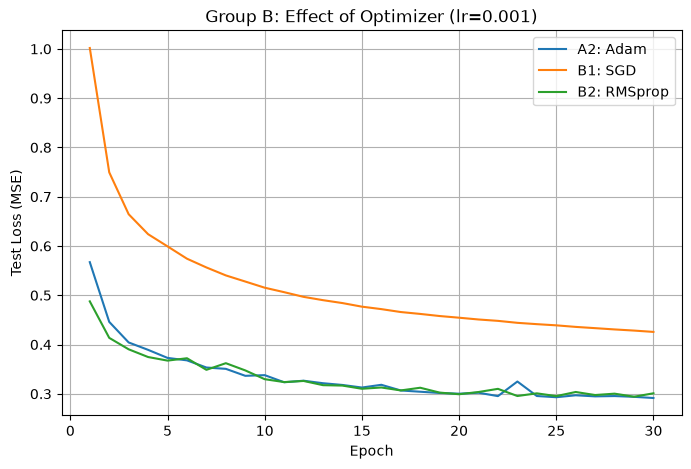

In [9]:
group_b_ids = ["A2", "B1", "B2"]  # A2 = Adam baseline, B1 = SGD, B2 = RMSprop
group_b = [r for r in results if r["run_id"] in group_b_ids]

plt.figure(figsize=(8, 5))
for r in group_b:
    plt.plot(range(1, r["epochs"] + 1), r["test_curve"], label=f"{r['run_id']}: {r['optimizer']}")
plt.xlabel("Epoch")
plt.ylabel("Test Loss (MSE)")
plt.title("Group B: Effect of Optimizer (lr=0.001)")
plt.legend()
plt.grid(True)
plt.show()

## Group C: Batch Size

Only the batch size changes (16, 32, 64, 128). Optimizer (Adam) and learning rate
(0.001) stay fixed at the best settings from Groups A and B. Batch size 32 (A2) is
reused as one of the four points.

In [10]:
# A2 already used batch_size=32, so we reuse it and only run the other three sizes.
for i, bs in enumerate([16, 64, 128], start=1):
    print(f"Running C{i}: batch_size={bs} ...")
    r = run_experiment(run_id=f"C{i}", optimizer_name="Adam", lr=0.001, batch_size=bs, epochs=30)
    results.append(r)
    print(f"  done -> train loss {r['final_train_loss']}, test loss {r['final_test_loss']}, {r['time_sec']}s")

Running C1: batch_size=16 ...
  done -> train loss 0.2781, test loss 0.2958, 42.8s
Running C2: batch_size=64 ...
  done -> train loss 0.287, test loss 0.2994, 14.9s
Running C3: batch_size=128 ...
  done -> train loss 0.3002, test loss 0.3167, 7.6s


## Group C Results

Test loss per epoch for each batch size (Adam, lr=0.001 fixed). Best batch size: 32.

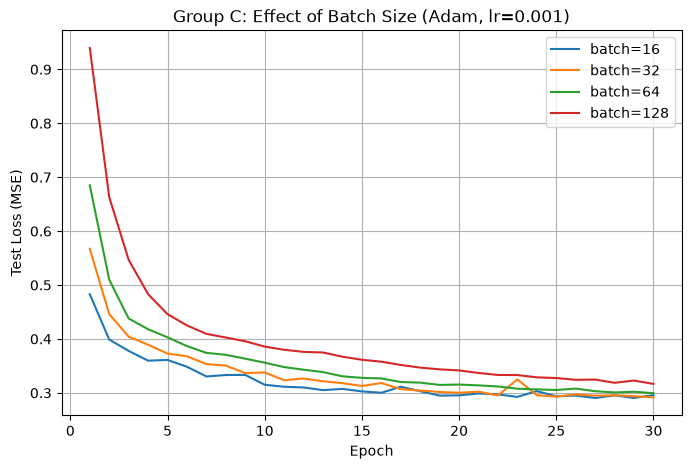

In [11]:
group_c_ids = ["C1", "A2", "C2", "C3"]  # 16, 32, 64, 128
group_c = [r for r in results if r["run_id"] in group_c_ids]
group_c = sorted(group_c, key=lambda r: r["batch_size"])  # sort by batch size for a clean legend

plt.figure(figsize=(8, 5))
for r in group_c:
    plt.plot(range(1, r["epochs"] + 1), r["test_curve"], label=f"batch={r['batch_size']}")
plt.xlabel("Epoch")
plt.ylabel("Test Loss (MSE)")
plt.title("Group C: Effect of Batch Size (Adam, lr=0.001)")
plt.legend()
plt.grid(True)
plt.show()

## Group D: Epochs

Using the best settings so far (Adam, lr=0.001, batch=32), we vary only the number
of epochs (10, 30, 60) to see whether more training keeps helping, or whether test
loss eventually plateaus or gets worse (overfitting). Epochs=30 (A2) is reused as
one of the three points.

In [12]:
for i, ep in enumerate([10, 60], start=1):
    print(f"Running D{i}: epochs={ep} ...")
    r = run_experiment(run_id=f"D{i}", optimizer_name="Adam", lr=0.001, batch_size=32, epochs=ep)
    results.append(r)
    print(f"  done -> train loss {r['final_train_loss']}, test loss {r['final_test_loss']}, {r['time_sec']}s")

Running D1: epochs=10 ...
  done -> train loss 0.3221, test loss 0.3379, 7.8s
Running D2: epochs=60 ...
  done -> train loss 0.259, test loss 0.2807, 47.2s


## Group D Results

Train and test loss per epoch for each epoch budget. We plot both curves together
to directly check for overfitting.

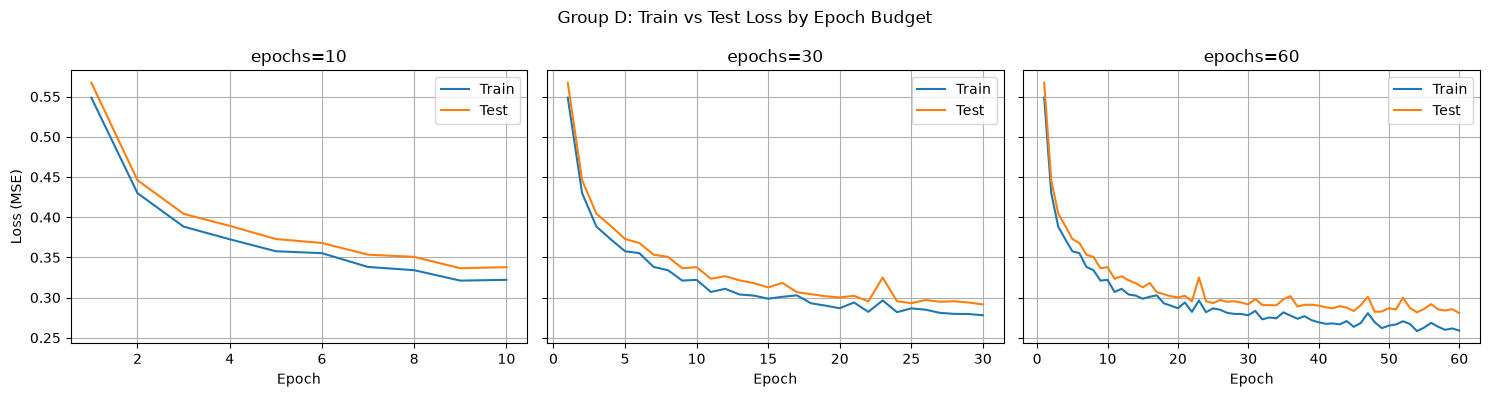

In [13]:
group_d_ids = ["D1", "A2", "D2"]  # 10, 30, 60
group_d = [r for r in results if r["run_id"] in group_d_ids]
group_d = sorted(group_d, key=lambda r: r["epochs"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, r in zip(axes, group_d):
    ax.plot(range(1, r["epochs"] + 1), r["train_curve"], label="Train")
    ax.plot(range(1, r["epochs"] + 1), r["test_curve"], label="Test")
    ax.set_title(f"epochs={r['epochs']}")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)

axes[0].set_ylabel("Loss (MSE)")
plt.suptitle("Group D: Train vs Test Loss by Epoch Budget")
plt.tight_layout()
plt.show()

## Master Comparison Table

All experiments from Groups A-D, sorted by test loss (best first).

In [14]:
summary_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("train_curve", "test_curve")}
    for r in results
])
summary_df = summary_df.sort_values("final_test_loss").reset_index(drop=True)
summary_df

,run_id,optimizer,lr,batch_size,epochs,final_train_loss,final_test_loss,time_sec
0,D2,Adam,0.0010,32,60,0.2590,0.2807,47.2
1,A2,Adam,0.0010,32,30,0.2780,0.2915,31.2
2,C1,Adam,0.0010,16,30,0.2781,0.2958,42.8
3,C2,Adam,0.0010,64,30,0.2870,0.2994,14.9
4,A1,Adam,0.0100,32,30,0.2820,0.2994,21.9
5,B2,RMSprop,0.0010,32,30,0.2894,0.3010,20.6
6,C3,Adam,0.0010,128,30,0.3002,0.3167,7.6
7,D1,Adam,0.0010,32,10,0.3221,0.3379,7.8
8,A3,Adam,0.0001,32,30,0.3798,0.3900,22.5
9,B1,SGD,0.0010,32,30,0.4117,0.4256,15.2


## Conclusion

We ran 13 controlled experiments on the Task 2.1 feed-forward network (California
Housing), changing one hyperparameter group at a time while keeping the dataset,
architecture, random seed, and evaluation procedure fixed.

**Learning Rate (Group A):** lr=0.0001 clearly underfit (test loss 0.39) — too small
a step size to converge in 30 epochs. lr=0.01 and lr=0.001 performed similarly, with
0.001 slightly ahead (0.2915 vs 0.2994).

**Optimizer (Group B):** Adam and RMSprop performed similarly (0.2915 vs 0.3010 test
loss), both clearly outperforming SGD (0.4256) at this learning rate. This does not
mean SGD is worse in general — only that it needs a larger learning rate than 0.001
to compete.

**Batch Size (Group C):** test loss steadily worsened as batch size increased (16:
0.2958, 32: 0.2915, 64: 0.2994, 128: 0.3167), while training time dropped sharply
(42.8s down to 7.6s). Batch size 32 offered the best balance of accuracy and speed.

**Epochs (Group D):** 10 epochs was clearly undertrained (test loss 0.3379). 30 to 60
epochs kept improving test loss (0.2915 -> 0.2807), but with diminishing returns —
training time nearly doubled for a small accuracy gain. Train and test loss stayed
close together even at 60 epochs, showing no sign of overfitting yet.

**Final configuration chosen:** Adam optimizer, learning rate 0.001, batch size 32,
30 epochs (run A2). While 60 epochs (D2) achieved a marginally lower test loss, the
extra training time (47.2s vs 31.2s, roughly 50% more) did not justify the small
accuracy gain (about 4%) for this task.

**What I learned:** how to design controlled experiments that isolate one variable at
a time, how learning rate, optimizer, batch size, and epoch count each affect training
differently, and how to weigh accuracy improvements against training time when
choosing a final configuration rather than always picking the single best number.

**Limitations:** each configuration was run once with a single random seed, so small
differences (for example, A1 vs A2) could partly reflect run-to-run variation rather
than a genuine, reliable difference between settings.